Device: cpu


preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.56k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]


Upload an image for analysis:


Saving 20251204_125921276_iOS.jpg to 20251204_125921276_iOS.jpg

Enter a question about the uploaded image:
what is in the image?


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1625: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


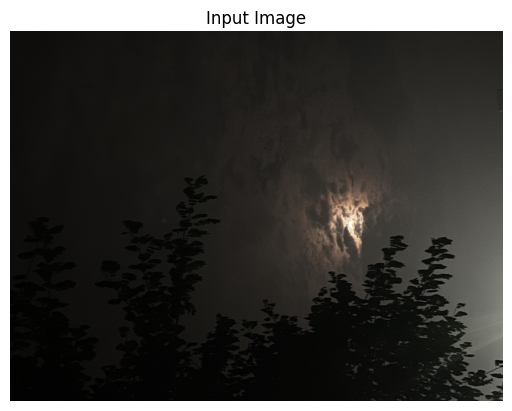


MULTIMODAL AI RESULT
--------------------------------------------------
Question: what is in the image?
Answer: moon


In [1]:
# Install libraries
!pip install -q transformers torch pillow matplotlib sentencepiece

import torch
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files
from transformers import BlipProcessor, BlipForQuestionAnswering

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# Load Model
model_name = "Salesforce/blip-vqa-base"

processor = BlipProcessor.from_pretrained(model_name)
model = BlipForQuestionAnswering.from_pretrained(model_name).to(device)

# Upload Image
print("\nUpload an image for analysis:")
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

image = Image.open(image_path).convert("RGB")

# Ask Question
question = input("\nEnter a question about the uploaded image:\n")

# Process Image and Question
inputs = processor(
    image,
    question,
    return_tensors="pt"
)

inputs = {k: v.to(device) for k, v in inputs.items()}

# Predict Answer
with torch.no_grad():
    output = model.generate(**inputs)

answer = processor.decode(output[0], skip_special_tokens=True)

# Display Image
plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

# Final Output
print("\nMULTIMODAL AI RESULT")
print("-"*50)
print("Question:", question)
print("Answer:", answer)